# Assignment 1: Entanglement-Based Quantum Communication


## Problem 1: Quantum Teleportation 
### Part A: Qiskit Implementation 

In [16]:
# Import required libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import numpy as np

### Step 1: Arbitrary Qubit Preparation (3 Marks)
We prepare an arbitrary quantum state on qubit 0 using Ry(θ) and Rz(φ) rotations.

**Chosen angles:**
- θ = 1.2 radians (avoiding special angles like 0, π/2, π, π/4)
- φ = 1.8 radians

In [2]:
# Define rotation angles
theta = 1.2  # θ ∈ (0.5, 2.5)
phi = 1.8    # φ ∈ (0.5, 2.5)

print(f"Chosen angles:")
print(f"θ (theta) = {theta} radians = {np.degrees(theta):.2f} degrees")
print(f"φ (phi) = {phi} radians = {np.degrees(phi):.2f} degrees")

Chosen angles:
θ (theta) = 1.2 radians = 68.75 degrees
φ (phi) = 1.8 radians = 103.13 degrees


### Step 2: Create Bell Pair (2 Marks)
We create a Bell state |φ+⟩ = (|00⟩ + |11⟩)/√2 between qubits 1 and 2.

**Qubit labeling:**
- Qubit 0 → Alice's unknown state (to be teleported)
- Qubit 1 → Alice's entangled qubit
- Qubit 2 → Bob's entangled qubit

In [3]:
# Create quantum circuit with 3 qubits and 1 classical bit for final measurement
qc = QuantumCircuit(3, 1)

# Step 1: Prepare arbitrary state on qubit 0 (Alice's unknown state)
qc.ry(theta, 0)
qc.rz(phi, 0)

# Add barrier for visualization
qc.barrier()

# Step 2: Create Bell pair between qubits 1 (Alice) and 2 (Bob)
qc.h(1)
qc.cx(1, 2)

# Add barrier
qc.barrier()

print("Circuit after Step 1 and Step 2 (State preparation and Bell pair creation):")

Circuit after Step 1 and Step 2 (State preparation and Bell pair creation):


### Step 3: Perform Teleportation Circuit (2 Marks)
We apply the Bell-measurement circuit between qubits 0 and 1:
- CNOT gate from qubit 0 to qubit 1
- Hadamard gate on qubit 0

Note: We do NOT measure at this stage (as per instructions)

In [4]:
# Step 3: Bell measurement circuit (without actual measurement)
qc.cx(0, 1)  # CNOT from qubit 0 to qubit 1
qc.h(0)      # Hadamard on qubit 0

# Add barrier
qc.barrier()

print("Bell measurement circuit applied (Step 3)")

Bell measurement circuit applied (Step 3)


### Step 4: Quantum Correction Step (3 Marks)
We apply controlled gates based on the measurement outcomes:
- CX(1, 2): Controlled-X from qubit 1 to qubit 2
- CZ(0, 2): Controlled-Z from qubit 0 to qubit 2

Note: We use quantum controlled gates directly (no classical bits or conditional gates)

In [5]:
# Step 4: Quantum correction gates
qc.cx(1, 2)  # Controlled-X: corrects based on Alice's qubit 1
qc.cz(0, 2)  # Controlled-Z: corrects based on Alice's qubit 0

# Add barrier
qc.barrier()

print("Quantum correction gates applied (Step 4)")

Quantum correction gates applied (Step 4)


### Step 5: Undo the Unitary U (2 Marks)
We apply the inverse rotation U† to Bob's qubit (qubit 2) by:
- Reversing the order of gates
- Using negative angles

Since U = Ry(θ) · Rz(φ), then U† = Rz(-φ) · Ry(-θ)

In [6]:
# Step 5: Apply inverse unitary U† to Bob's qubit (qubit 2)
qc.rz(-phi, 2)    # Rz with negative angle
qc.ry(-theta, 2)  # Ry with negative angle

# Add barrier
qc.barrier()

print("Inverse unitary U† applied to Bob's qubit (Step 5)")

Inverse unitary U† applied to Bob's qubit (Step 5)


### Step 6: Measurement and Histogram (2 Marks)
We measure only Bob's qubit (qubit 2) and run the simulation with 5000+ shots.


Complete Quantum Teleportation Circuit:


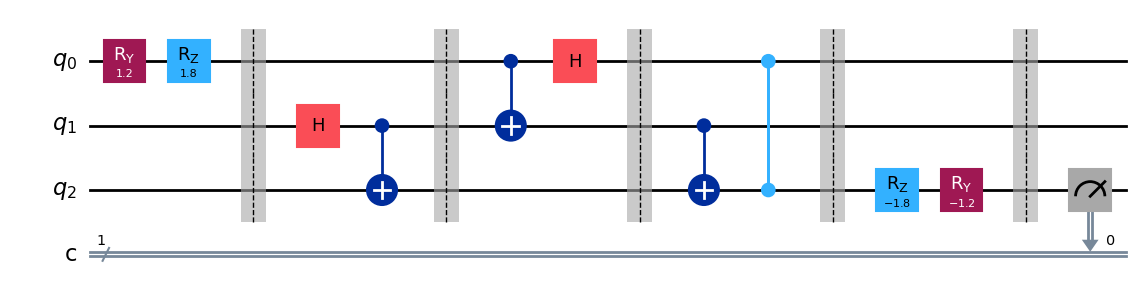

In [7]:
# Step 6: Measure Bob's qubit only (qubit 2 -> classical bit 0)
qc.measure(2, 0)

# Draw the complete circuit
print("\nComplete Quantum Teleportation Circuit:")
qc.draw(output='mpl')


Measurement results:
{'0': 5000}


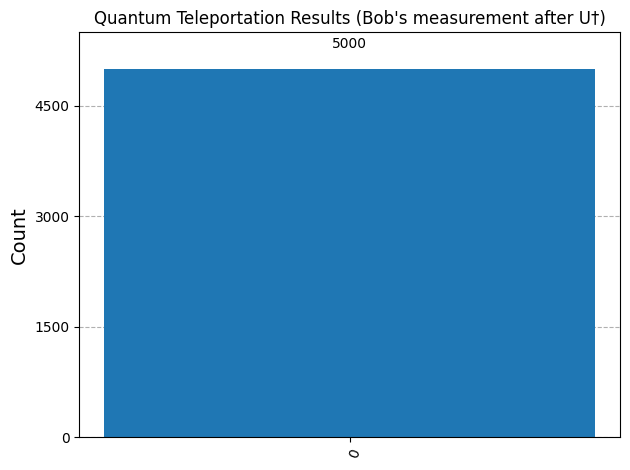

In [8]:
# Run the simulation
sim = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts = result.get_counts()

print("\nMeasurement results:")
print(counts)

# Plot histogram
plot_histogram(counts, title="Quantum Teleportation Results (Bob's measurement after U†)")

---
---
# Problem 2: Superdense Coding 
## Part A: Qiskit Implementation 

### Superdense Coding Protocol

Superdense coding allows Alice to send **2 classical bits** to Bob using only **1 qubit**, provided they share an entangled Bell pair beforehand.

**Encoding scheme:**
- Message **00** → Apply **I** (Identity - do nothing)
- Message **01** → Apply **Z** gate
- Message **10** → Apply **X** gate  
- Message **11** → Apply **XZ** (X followed by Z)

**Chosen message: 10** (binary)

In [37]:
# Create quantum circuit for superdense coding
# 2 qubits and 2 classical bits for measurement
qc_superdense = QuantumCircuit(2, 2)

# Step 1: Create Bell pair |φ+⟩ = (|00⟩ + |11⟩)/√2
# Alice has qubit 0, Bob has qubit 1
qc_superdense.h(0)
qc_superdense.cx(0, 1)

qc_superdense.barrier(label="Entangled")

print("Step 1: Bell pair created between Alice (qubit 0) and Bob (qubit 1)")

Step 1: Bell pair created between Alice (qubit 0) and Bob (qubit 1)


In [38]:
# Step 2: Alice encodes her message (chosen message: 10)
message = "10"
print(f"\nAlice's message to encode: {message}")

if message == "00":
    # Do nothing (Identity)
    print("Encoding 00: Apply I (Identity - no gates)")
    pass
elif message == "01":
    # Apply Z gate
    print("Encoding 01: Apply Z gate")
    qc_superdense.z(0)
elif message == "10":
    # Apply X gate
    print("Encoding 10: Apply X gate")
    qc_superdense.x(0)
elif message == "11":
    # Apply X then Z
    print("Encoding 11: Apply X then Z gates")
    qc_superdense.x(0)
    qc_superdense.z(0)

qc_superdense.barrier(label="Encoded")


Alice's message to encode: 10
Encoding 10: Apply X gate


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [39]:
# Step 3: Alice sends her qubit to Bob
print("\nAlice sends her qubit (qubit 0) to Bob...")
print("Bob now has both qubits")

qc_superdense.barrier(label="Sent to Bob")


Alice sends her qubit (qubit 0) to Bob...
Bob now has both qubits


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [40]:
# Step 4: Bob performs Bell-basis measurement
# First, he "un-does" the Bell state creation
qc_superdense.cx(0, 1)  # CNOT
qc_superdense.h(0)      # Hadamard

qc_superdense.barrier(label="Bell decode")

print("\nBob applies Bell-basis decoding (CNOT + H)")


Bob applies Bell-basis decoding (CNOT + H)



Bob measures both qubits

Complete Superdense Coding Circuit:


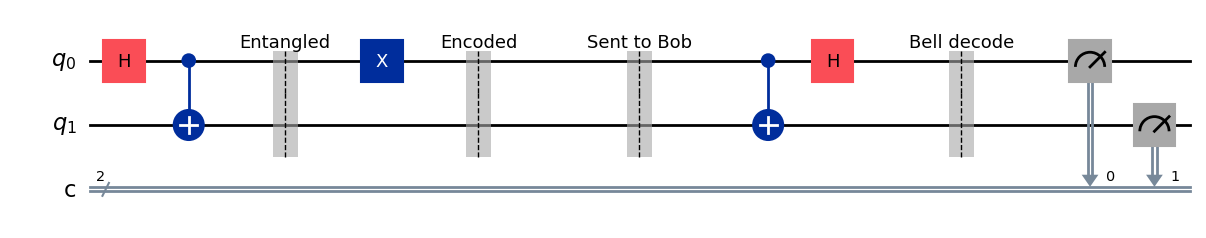

In [41]:
# Step 5: Bob measures both qubits
qc_superdense.measure([0, 1], [0, 1])

print("\nBob measures both qubits")
print("\nComplete Superdense Coding Circuit:")
qc_superdense.draw(output='mpl')


Measurement results:
{'10': 5000}


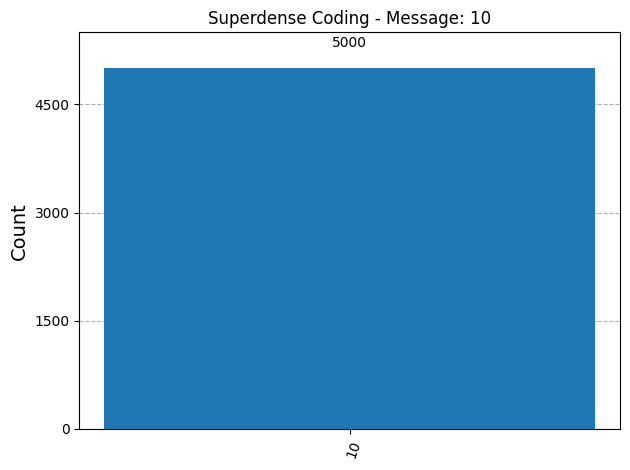

In [42]:
# Run simulation
sim = AerSimulator()
result = sim.run(qc_superdense, shots=5000).result()
counts = result.get_counts()

print("\nMeasurement results:")
print(counts)

# Plot histogram
plot_histogram(counts, title=f"Superdense Coding - Message: {message}")

### Verification

The histogram should show that Bob measures the exact message bits Alice encoded.

**Understanding Qiskit bit ordering:**
- In Qiskit, measurement results are displayed as strings where:
  - **Rightmost bit** = qubit 0
  - **Leftmost bit** = qubit 1 (or highest qubit number)
- For result **'10'** → qubit 1 = 1, qubit 0 = 0

**For our message '10':**
- Alice encoded message: **10** (binary)
- Expected measurement: **'10'** 
- This means: qubit 0 measured 0, qubit 1 measured 1
- Result: **'10'**  (100% probability confirms success)

**Key insight:** The 2-bit classical message '10' is successfully transmitted using only 1 qubit (Alice's qubit 0), thanks to the pre-shared entanglement!